<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/A_Hybrid_CNN%E2%80%93Transformer_Framework_for_Skin_Cancer_Classification_Using_EfficientNetB3_and_Self_Attention_on_the_HAM10000_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
base_path = "/content/drive/MyDrive/Skin Cancer MNIST HAM10000"

split_path = os.path.join(base_path, "split")
train_path = os.path.join(split_path, "train")
test_path  = os.path.join(split_path, "test")

In [ ]:
IMG_SIZE = 300
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.


In [ ]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# CNN BACKBONE
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output

# =========================
# TRANSFORMER BLOCK
# =========================

x = Reshape((-1, x.shape[-1]))(x)

attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = Add()([x, attn])
x = LayerNormalization()(x)

ffn = Dense(512, activation='relu')(x)
ffn = Dense(x.shape[-1])(ffn)

x = Add()([x, ffn])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)

# =========================
# CLASSIFIER HEAD
# =========================

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(num_classes, activation='softmax')(x)

model = Model(input_layer, output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 14,862,902 (56.70 MB)

 Trainable params: 7,632,001 (29.11 MB)

 Non-trainable params: 7,230,901 (27.58 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("hybrid_best.h5", save_best_only=True)
]

In [10]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3437 - loss: 2.2394 

251/251 ━━━━━━━━━━━━━━━━━━━━ 3469s 14s/step - accuracy: 0.4546 - loss: 1.9086 - val_accuracy: 0.7079 - val_loss: 0.9783 - learning_rate: 1.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6271 - loss: 1.3411

251/251 ━━━━━━━━━━━━━━━━━━━━ 2670s 11s/step - accuracy: 0.6453 - loss: 1.2744 - val_accuracy: 0.7299 - val_loss: 0.8313 - learning_rate: 1.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6885 - loss: 1.1366

251/251 ━━━━━━━━━━━━━━━━━━━━ 2705s 11s/step - accuracy: 0.6950 - loss: 1.1106 - val_accuracy: 0.7524 - val_loss: 0.7477 - learning_rate: 1.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7204 - loss: 0.9694

251/251 ━━━━━━━━━━━━━━━━━━━━ 2696s 11s/step - accuracy: 0.7255 - loss: 0.9468 - val_accuracy: 0.7609 - val_loss: 0.7409 - learning_rate: 1.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2773s 11s/step - accuracy: 0.7400 - loss: 0.8516 - val_accuracy: 0.7733 - val_loss: 0.7539 - learning_rate: 1.0000e-04
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2691s 11s/step - accuracy: 0.7545 - loss: 0.8006 - val_accuracy: 0.7429 - val_loss: 0.7587 - learning_rate: 1.0000e-04
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7622 - loss: 0.7685

251/251 ━━━━━━━━━━━━━━━━━━━━ 2783s 11s/step - accuracy: 0.7660 - loss: 0.7631 - val_accuracy: 0.7788 - val_loss: 0.7232 - learning_rate: 1.0000e-04
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7870 - loss: 0.6981

251/251 ━━━━━━━━━━━━━━━━━━━━ 2784s 11s/step - accuracy: 0.7811 - loss: 0.6906 - val_accuracy: 0.7748 - val_loss: 0.6714 - learning_rate: 1.0000e-04
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2730s 11s/step - accuracy: 0.7841 - loss: 0.6761 - val_accuracy: 0.7763 - val_loss: 0.7347 - learning_rate: 1.0000e-04
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 2838s 11s/step - accuracy: 0.7934 - loss: 0.6418 - val_accuracy: 0.7903 - val_loss: 0.6739 - learning_rate: 1.0000e-04


In [11]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Final Loss:", loss)
print("Final Accuracy: {:.2f}%".format(acc * 100))
print("="*40)

63/63 ━━━━━━━━━━━━━━━━━━━━ 442s 7s/step - accuracy: 0.7748 - loss: 0.6714
Final Loss: 0.6714085936546326
Final Accuracy: 77.48%


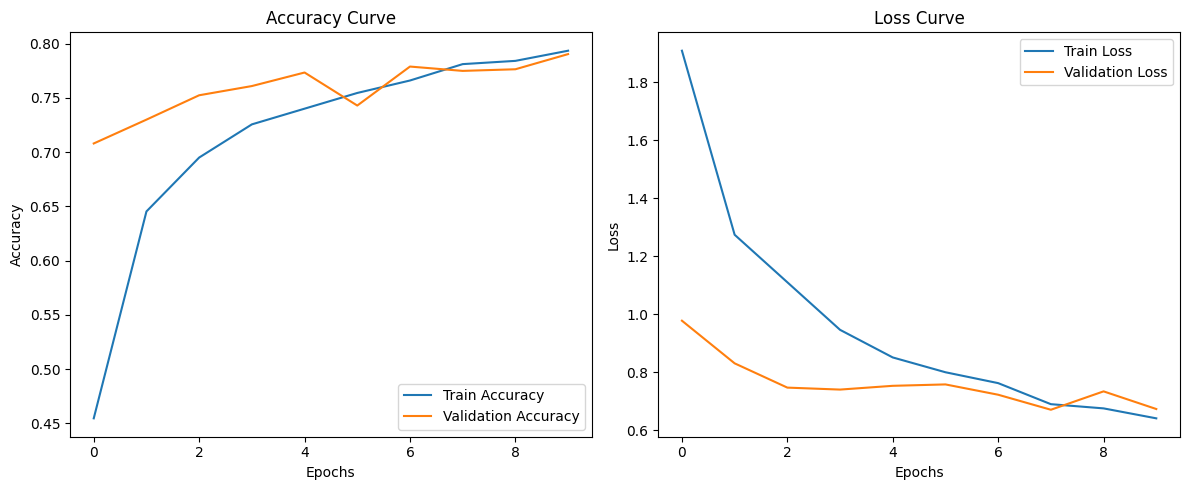

In [12]:
plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 436s 7s/step


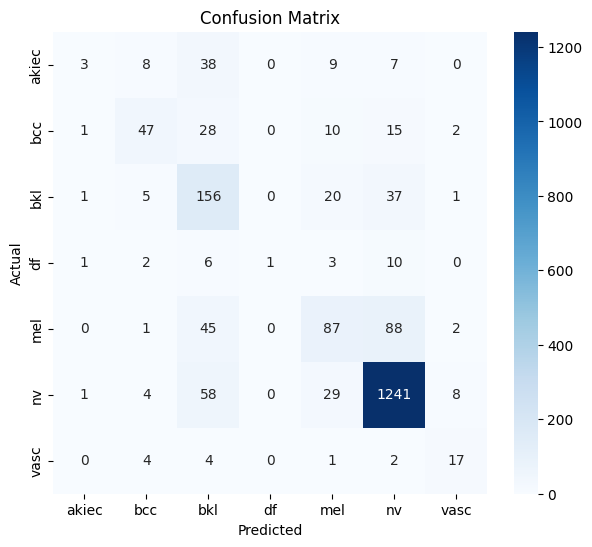

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       akiec       0.43      0.05      0.08        65
         bcc       0.66      0.46      0.54       103
         bkl       0.47      0.71      0.56       220
          df       1.00      0.04      0.08        23
         mel       0.55      0.39      0.46       223
          nv       0.89      0.93      0.91      1341
        vasc       0.57      0.61      0.59        28

    accuracy                           0.77      2003
   macro avg       0.65      0.45      0.46      2003
weighted avg       0.77      0.77      0.76      2003



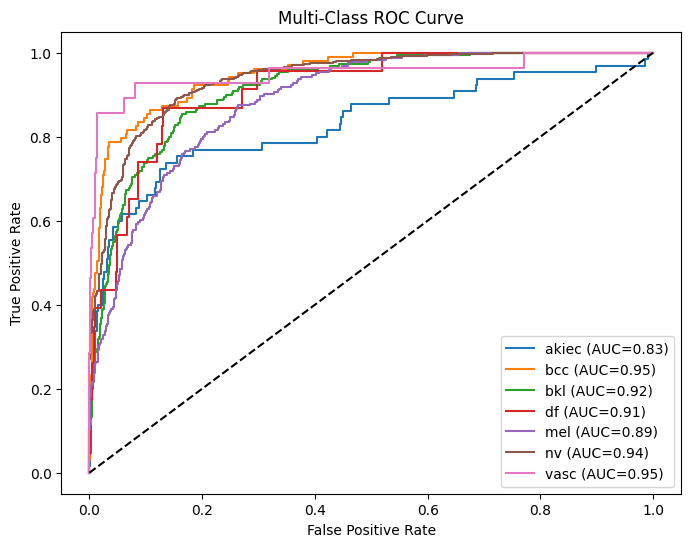

In [16]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

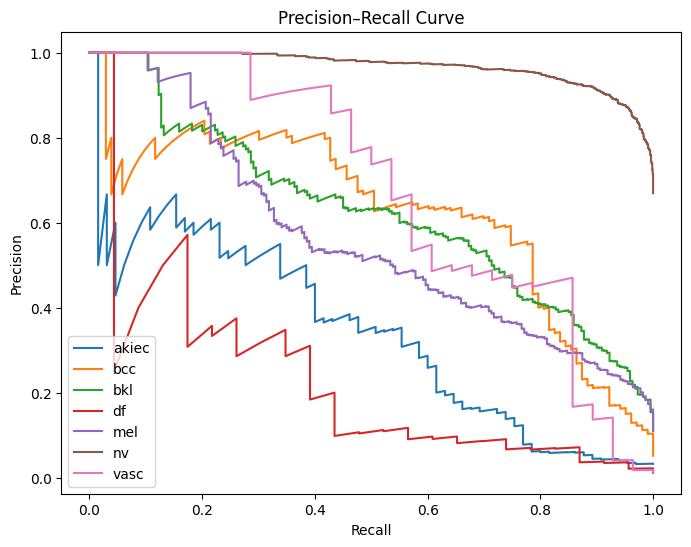

In [17]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(recall, precision, label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score (Weighted):", f1)

F1 Score (Weighted): 0.7583274502359486
